In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("smartcart_customers.csv")

In [3]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Pre-processing

## Handling Missing Values

In [6]:
from sklearn.impute import SimpleImputer

num_imp=SimpleImputer(strategy="median")

df["Income"]=num_imp.fit_transform(df[["Income"]])

In [7]:
 # df.isnull().sum()

## Feature Engineering

In [8]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [9]:
# Since we would be using clustering algorithms, those do not perform well on the date data, hence we need to convert it in numerical data.

df["Age"]= 2026 - df["Year_Birth"]

df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_date=df["Dt_Customer"].max()

df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days #(dt.days gives total numbers of days)

In [10]:
# We have different columns for spendings, we will put all spendings as Total spendings

df["Total_spendings"] = df['MntWines'] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [11]:
# We have two children columns, we will combine into one.

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [12]:
# Education

df["Education"].value_counts()

df["Education"]=df["Education"].replace({
    "Basic":"UnderGraduate",
    "2n Cycle":"UnderGraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate",
    "PhD":"Postgraduate"
})

In [13]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [14]:
df["Marital_Status"].value_counts()

df["Relation"]=df["Marital_Status"].replace({
    "Married":"Married",
    "Together":"Married",
    "Single":"Single",
    "Divorced":"Single",
    "Widow":"Single",
    "Alone":"Single",
    "Absurd":"Single",
    "YOLO":"Single"

})

In [15]:
df["Relation"].value_counts()


Relation
Married    1444
Single      796
Name: count, dtype: int64

## Drop Columns

In [16]:
cols=['ID','Year_Birth','Kidhome','Teenhome','Dt_Customer',"Marital_Status"]
spending_cols=['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

cols_to_drop = cols + spending_cols

cleaned_df=df.drop(columns=cols_to_drop)

In [17]:
cleaned_df.shape

(2240, 15)

In [18]:
df.shape

(2240, 27)

In [20]:
cleaned_df.head(2)

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spendings,Total_Children,Relation
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Single
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Single


# Outlier Detection

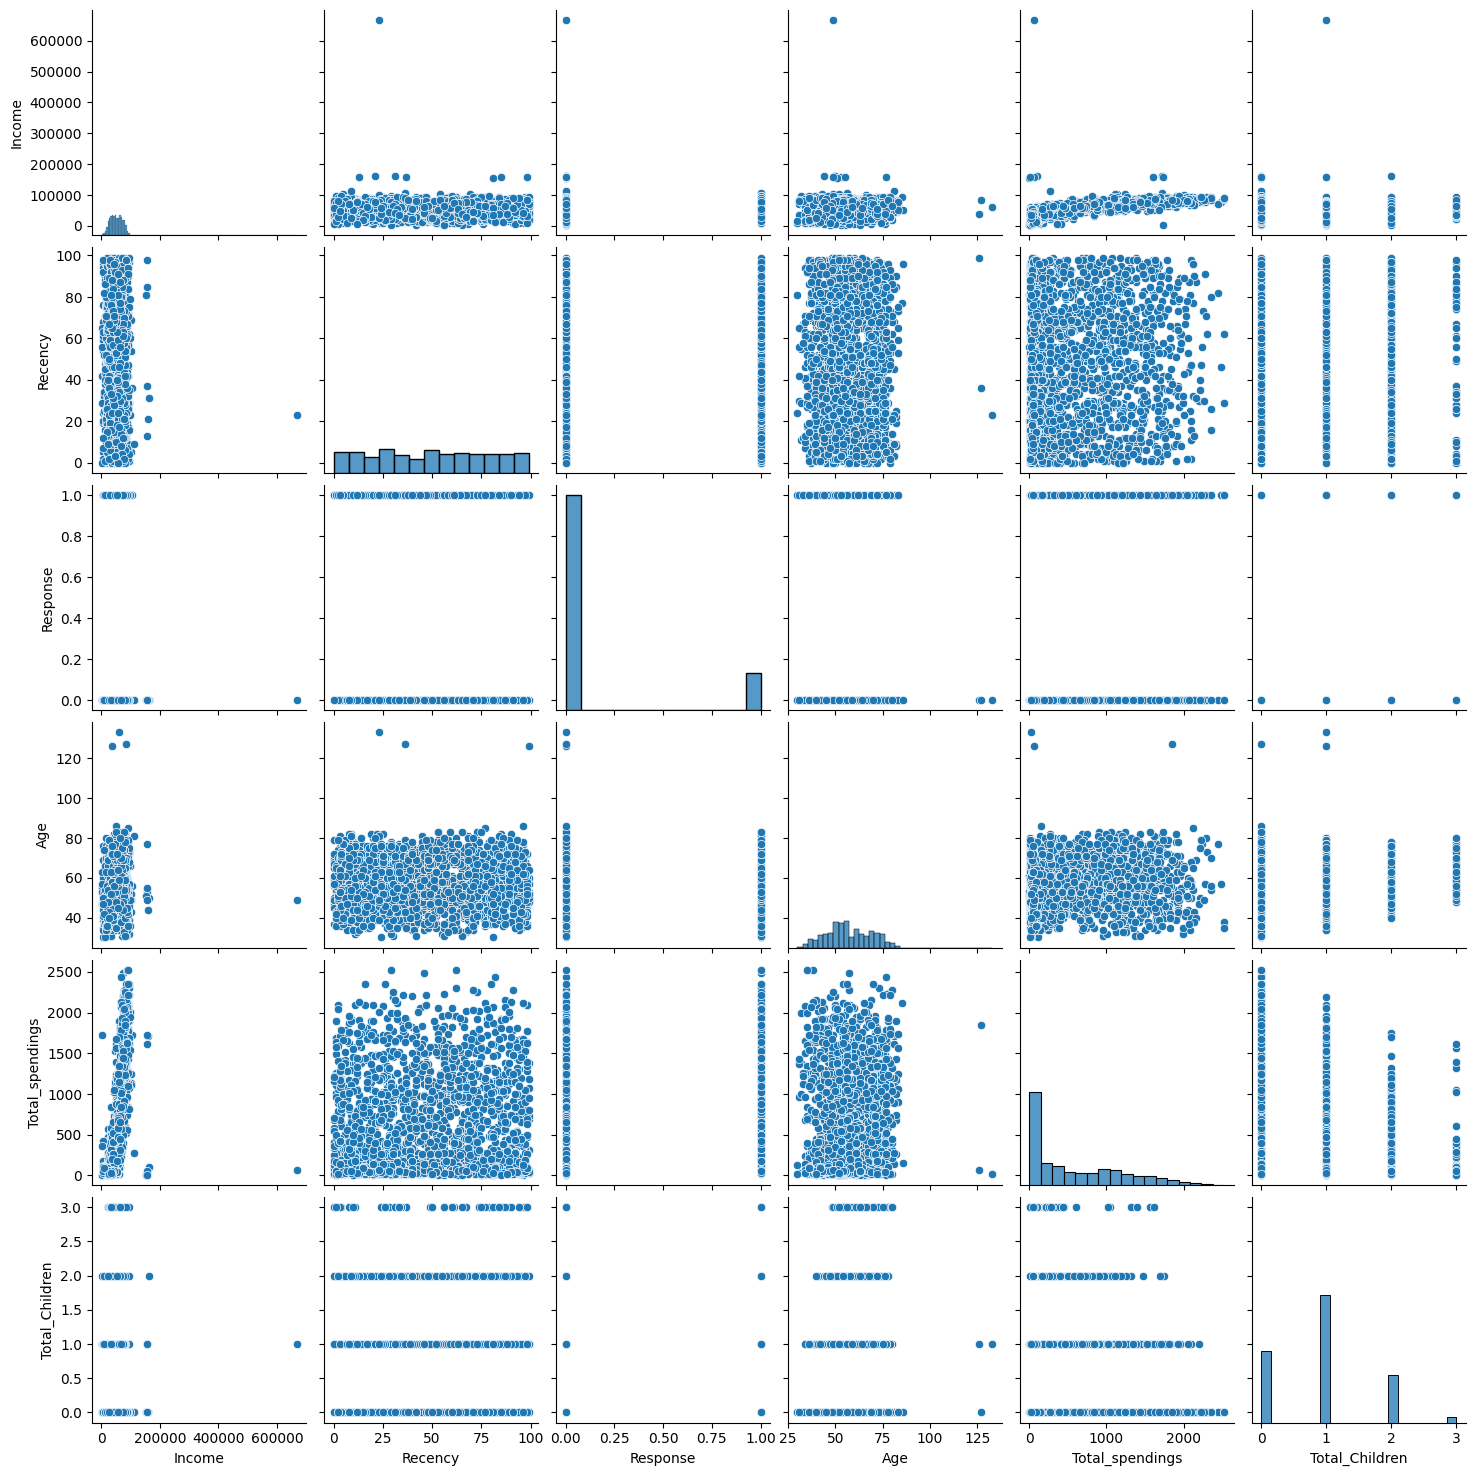

In [23]:
cols=["Income","Recency","Response","Age","Total_spendings","Total_Children"]

sns.pairplot(cleaned_df[cols])

In [24]:
print("data size with outliers:", len(cleaned_df))

cleaned_df=cleaned_df[(cleaned_df["Age"]<90)]
cleaned_df=cleaned_df[(cleaned_df["Income"]<600_000)]

print("data size without outliers:", len(cleaned_df))

data size with outliers: 2240
data size without outliers: 2236


## Correlation Heatmap

<Axes: >

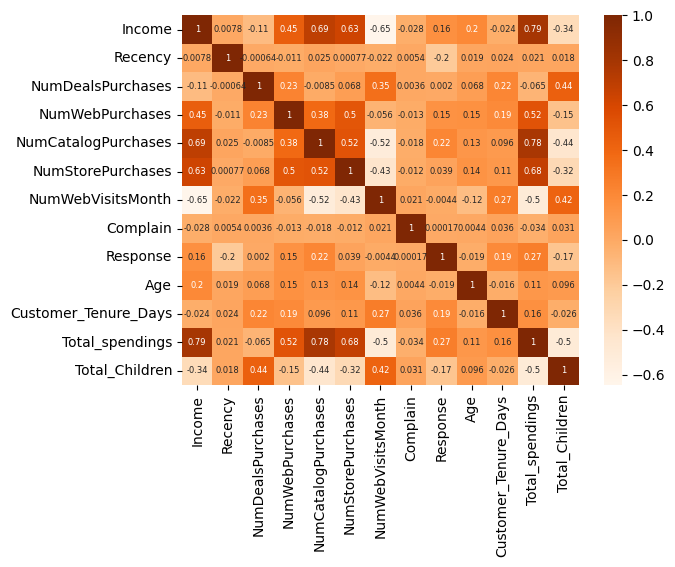

In [38]:

num_cols=cleaned_df.select_dtypes(include="number")

corr=num_cols.corr()

plt.Figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            annot_kws={"size":6},
            cmap="Oranges",
            fmt='.2g'
            )




In [39]:

# CORRELATION ANALYSIS


# --- Strong Positive Correlations (r >= 0.6) ---
# Income <-> Total_spendings         : 0.79
# Income <-> NumCatalogPurchases     : 0.69
# NumCatalogPurchases <-> Total_spendings : 0.78
# NumStorePurchases <-> Total_spendings   : 0.68
# Income <-> NumStorePurchases       : 0.63
# Interpretation: Higher income customers spend more overall
# and purchase more via catalog/store channels.

# --- Strong Negative Correlations (r <= -0.5) ---
# Income <-> NumWebVisitsMonth              : -0.65
# NumCatalogPurchases <-> NumWebVisitsMonth : -0.52
# NumWebVisitsMonth <-> Total_spendings     : -0.50
# Total_spendings <-> Total_Children        : -0.50
# Interpretation: Frequent web visitors tend to have lower
# income and spend less. Households with more children spend
# less overall (likely budget constrained).

# Encoding

In [40]:
from sklearn.preprocessing import OneHotEncoder

In [41]:
cleaned_df.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spendings,Total_Children,Relation
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Single
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Single
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Married
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Married
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Married


In [50]:
cat_cols=cleaned_df.select_dtypes(include="object").columns

ohe=OneHotEncoder()

encoded=ohe.fit_transform(cleaned_df[cat_cols])

encoded_df=pd.DataFrame(encoded.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=cleaned_df.index)


final_df=pd.concat([cleaned_df.drop(columns=cat_cols),encoded_df],axis=1)


In [51]:
final_df.shape

(2236, 18)

# Scaling

In [52]:
X=final_df

In [54]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

# Data Visualisation by PCA

In [90]:
from sklearn.decomposition import PCA

pca=PCA(n_components=3, random_state=42)

X_pca=pca.fit_transform(X_scaled)

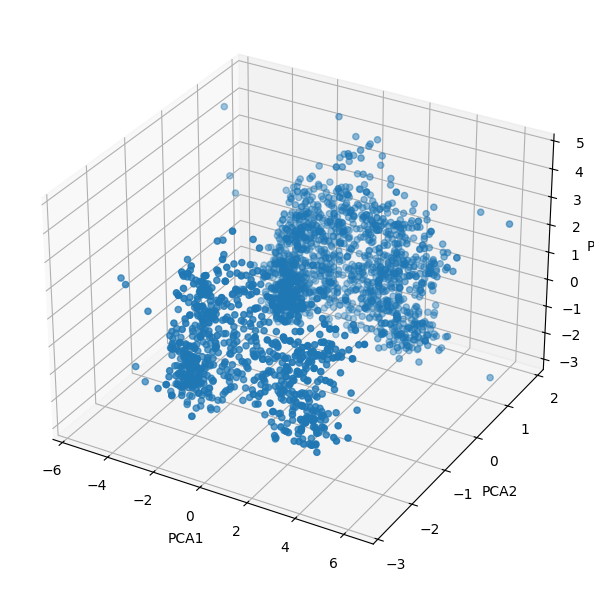

In [91]:
fig=plt.figure(figsize=(8,6))

ax= fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

plt.tight_layout()

# Choosing Best K using Elbow method and Silhoutte Score

## Elbow method

In [92]:
import warnings
warnings.filterwarnings("ignore")

In [93]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [94]:
knee=KneeLocator(x=range(1,11),y=wcss,curve="convex", direction="decreasing")
optimal_k= knee.elbow

In [95]:
print(optimal_k)

4


Text(0, 0.5, 'WCSS')

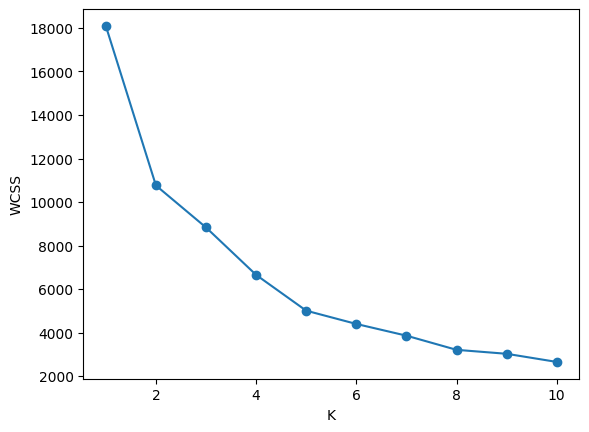

In [103]:
plt.plot(range(1,11),wcss,marker="o")

plt.xlabel("K")
plt.ylabel("WCSS")


# Silhoutte Score

In [104]:
from sklearn.metrics import silhouette_score

scores=[]

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

Text(0, 0.5, 'scores')

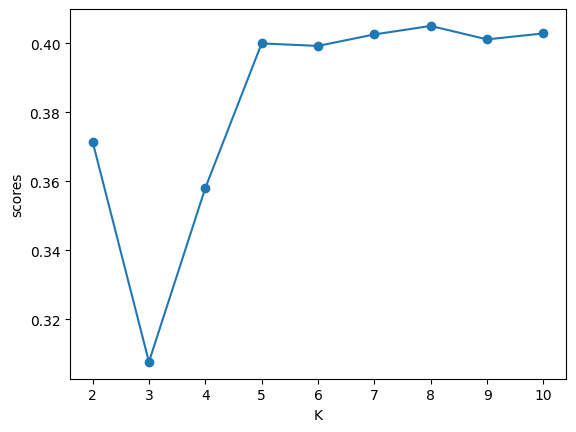

In [105]:
plt.plot(range(2,11),scores,marker="o")

plt.xlabel("K")
plt.ylabel("scores")


### Now when we plot wcss and scores, the meeting point is the K to be used. 

Text(0, 0.5, 'Silhoutte score')

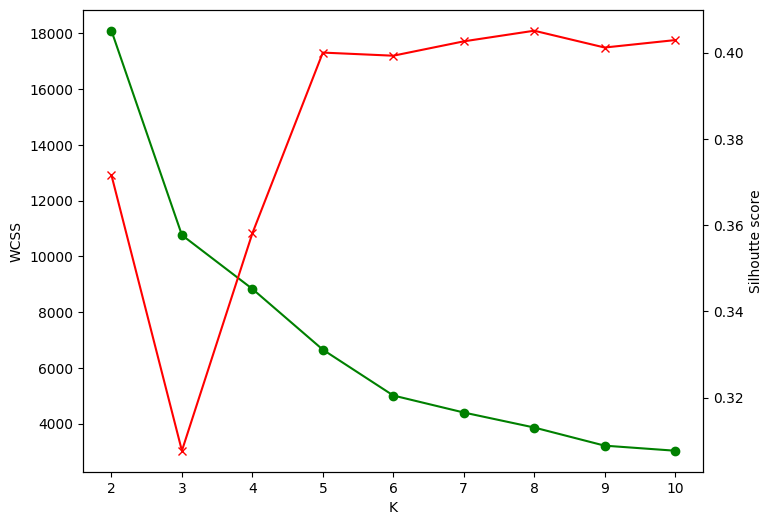

In [111]:
fig,ax1 = plt.subplots(figsize=(8,6))

ax1.plot(range(2,11),wcss[:len(range(2,11))],color="green",marker="o")

ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx()

ax2.plot(range(2,11),scores[:len(range(2,11))],color="red",marker="x")

ax2.set_ylabel("Silhoutte score")


# Clustering

## KMeans

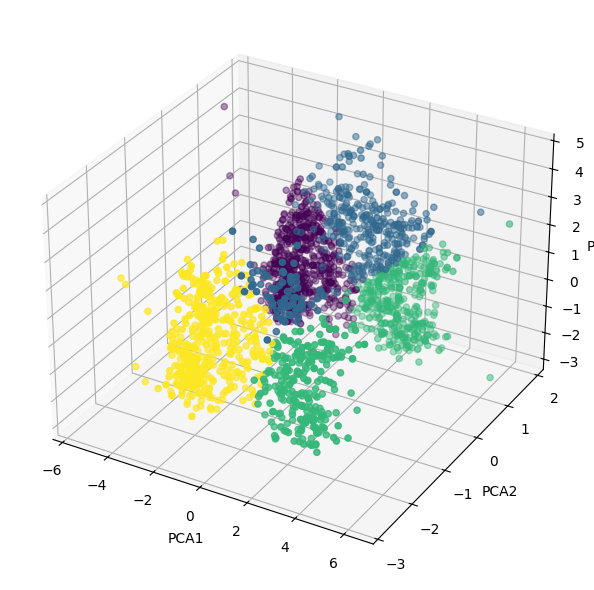

In [115]:
from sklearn.cluster import KMeans


kmeans=KMeans(n_clusters=4,random_state=42)

kmeans_labels=kmeans.fit_predict(X_pca)

fig=plt.figure(figsize=(8,6))

ax= fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=kmeans_labels)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

plt.tight_layout()



## Agglomerative Clustering

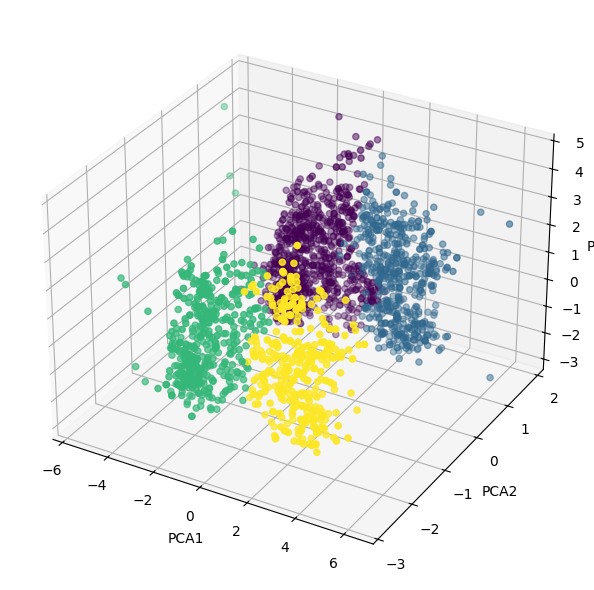

In [116]:
from sklearn.cluster import AgglomerativeClustering

agglo=AgglomerativeClustering(n_clusters=4,linkage="ward")

agglo_labels=agglo.fit_predict(X_pca)


fig=plt.figure(figsize=(8,6))

ax= fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=agglo_labels)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

plt.tight_layout()

## Clusters Characterization

In [127]:
# Since AgglomerativeClustering is giving us a correct distinction between the datapoints. We will use it.

X["labels"]=agglo_labels

X.head(2)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spendings,Total_Children,Education_Graduate,Education_Postgraduate,Education_UnderGraduate,Relation_Married,Relation_Single,labels
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,0.0,1.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,0.0,1.0,2


<Axes: xlabel='labels', ylabel='count'>

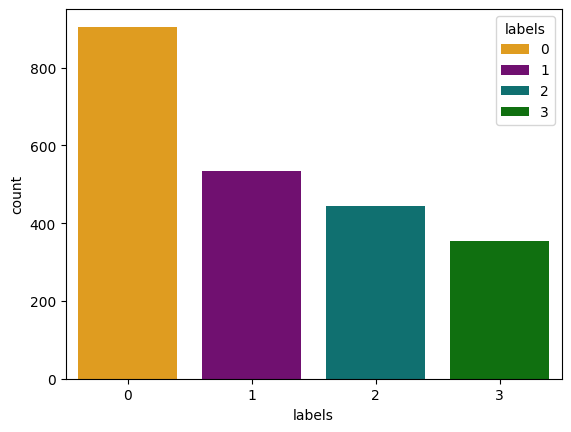

In [128]:
colour=["Orange","Purple","Teal","Green"]

sns.countplot(x=X["labels"],palette=colour,hue=X["labels"])


<Axes: xlabel='Total_spendings', ylabel='Income'>

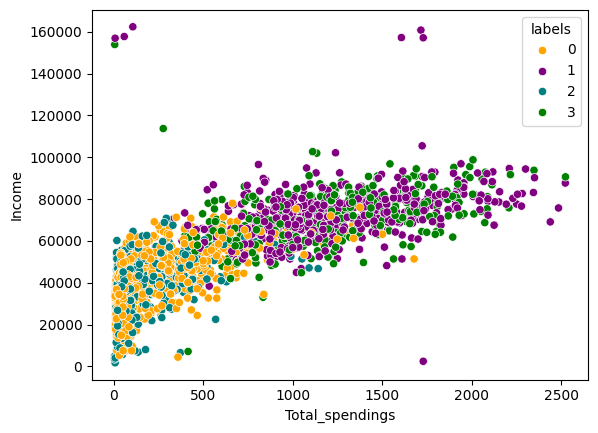

In [124]:
# Since Income and Spending patterns

sns.scatterplot(x=cleaned_df["Total_spendings"],y=cleaned_df["Income"],palette=colour,hue=cleaned_df["labels"])

In [125]:

# CLUSTER LABEL VALIDATION (matches planned segmentation)

# 0 (Orange) : Income ~5k-70k   | Spending ~0-800    -> Orange    "Low/Moderate Income & Spending"
# 1 (Purple) : Income ~60k-163k | Spending ~1000-2500 -> Purple   "High Income, High Spending"
# 2 (Teal)   : Income ~0-40k    | Spending ~0-800    -> Teal "Low Income, Low Spend"
# 3 (Green)  : Income ~60k-100k | Spending ~800-2500 -> Green  "Moderate-High Income, High Spend"


In [133]:
# Cluster Summary

cluster_summary=X.groupby("labels").mean()

print(cluster_summary)

              Income    Recency  NumDealsPurchases  NumWebPurchases  \
labels                                                                
0       39680.580110  48.914917           2.594475         3.153591   
1       72808.445693  49.202247           1.958801         5.687266   
2       36960.143018  48.319820           2.594595         2.713964   
3       70722.681303  50.504249           1.855524         5.790368   

        NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
labels                                                                        
0                  0.969061           4.143646           6.307182  0.011050   
1                  5.498127           8.659176           3.580524  0.005618   
2                  0.837838           3.623874           6.659910  0.011261   
3                  5.014164           8.430595           3.728045  0.005666   

        Response        Age  Customer_Tenure_Days  Total_spendings  \
labels                      

In [ ]:

# CLUSTER SUMMARY — Customer Segmentation

# Two things mainly separate the 4 clusters: income level and
# marital status. Higher income = higher spending across the board.
#
# Cluster 0 — Married Families on a Budget
#   - Income ~$40k | Spending ~$220 (low)
#   - Married, most children on average
#   - High web visits but low conversion; low campaign response
#
# Cluster 1 — Married, High-Value, Loyal
#   - Income ~$73k | Spending ~$1,237 (highest)
#   - Married, fewer children
#   - Buys directly via catalog/store, low web browsing
#   - Longest tenure, decent campaign response (~17%)
#
# Cluster 2 — Single, Budget-Conscious
#   - Income ~$37k | Spending ~$166 (lowest)
#   - Single, tends to have kids
#   - Highest web visits but lowest purchases; low response rate
#
# Cluster 3 — Single, High-Value, Most Responsive
#   - Income ~$71k | Spending ~$1,190 (2nd highest)
#   - Single, fewest children
#   - Buys via catalog/store, low web browsing
#   - Highest campaign response (~32%) -> best marketing target
#
# TAKEAWAY: Income drives spending; marital status cleanly splits
# the segments. Clusters 1 & 3 (high income) buy directly with
# little browsing. Clusters 0 & 2 (low income) browse a lot but
# convert rarely. Cluster 3 is the top priority for campaigns —
# highest spend + highest response rate.